## Cell 1- Imports 

In [11]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ── Paste step_3_model.py contents directly ───────────────────────────────────

def wind_direction_loss(y_true, y_pred):
    diff = y_pred - y_true
    return 1.0 - tf.square(tf.cos(diff))


def residual_block(x, filters=64):
    shortcut = x
    x = layers.Conv2D(filters, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), padding="same")(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.BatchNormalization()(x)
    return x


def build_m64rn4():
    inputs = tf.keras.Input(shape=(49, 49, 1), name="sar_patch")
    x = residual_block(inputs, filters=64)
    x = residual_block(x,      filters=64)
    x = residual_block(x,      filters=64)
    x = residual_block(x,      filters=64)
    x = layers.Flatten()(x)
    x = layers.Dense(512)(x)
    x = layers.ReLU()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128)(x)
    x = layers.ReLU()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(32)(x)
    x = layers.ReLU()(x)
    x = layers.BatchNormalization()(x)
    outputs = layers.Dense(1, name="wind_direction_rad")(x)
    return Model(inputs, outputs, name="M64RN4")

print("Architecture loaded.")

Architecture loaded.


## Cell 2- Data Loading Function

In [12]:
def load_training_data(patches_path, labels_path):
    """
    Load preprocessed SAR patches and ERA5 direction labels.

    patches_path : path to .npy file of shape (N, 49, 49)
    labels_path  : path to .npy file of shape (N,) — directions in radians

    Returns: X (N, 49, 49, 1), y (N,)
    """
    X = np.load(patches_path).astype(np.float32)
    y = np.load(labels_path).astype(np.float32)

    # Add channel dimension if missing
    if X.ndim == 3:
        X = X[..., np.newaxis]  # (N, 49, 49, 1)

    print(f"Patches loaded:  {X.shape}")
    print(f"Labels loaded:   {y.shape}")
    print(f"Label range:     {y.min():.3f} to {y.max():.3f} radians")
    print(f"Label range:     {np.degrees(y.min()):.1f}° to {np.degrees(y.max()):.1f}°")

    return X, y

## Cell 3- Data Preparation Function

In [13]:
def prepare_data(X, y, val_split=0.1):
    """
    Shuffle and split data into training and validation sets.
    Paper used 90/10 split.

    Returns: X_train, X_val, y_train, y_val
    """
    N = len(X)
    idx = np.random.permutation(N)
    X, y = X[idx], y[idx]

    split = int((1 - val_split) * N)
    X_train, X_val = X[:split], X[split:]
    y_train, y_val = y[:split], y[split:]

    print(f"\nTraining samples:   {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")

    return X_train, X_val, y_train, y_val

## Cell 4- Training Function

In [14]:
def train(X_train, X_val, y_train, y_val,
          epochs=500, batch_size=64, learning_rate=0.001,
          model_save_path="best_model.keras"):
    """
    Train M64RN4 ResNet on SAR patches.

    Follows paper exactly:
    - Adam optimiser, lr=0.001
    - Batch size 64
    - Early stopping with patience=15
    - Save best weights only
    """
    # Build and compile model
    model = build_m64rn4()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=wind_direction_loss,
    )
    print(f"\nModel built. Total parameters: {model.count_params():,}")

    # Callbacks
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1,
    )
    checkpoint = ModelCheckpoint(
        model_save_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    )

    print(f"\nStarting training...")
    print(f"Epochs:       up to {epochs} (early stopping patience=15)")
    print(f"Batch size:   {batch_size}")
    print(f"Learning rate: {learning_rate}")
    print(f"Model saved to: {model_save_path}")
    print("-" * 60)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop, checkpoint],
        verbose=1,
    )

    best_val_loss = min(history.history["val_loss"])
    best_epoch    = history.history["val_loss"].index(best_val_loss) + 1

    print("-" * 60)
    print(f"Training complete.")
    print(f"Best val loss: {best_val_loss:.4f} at epoch {best_epoch}")
    print(f"Model saved → {model_save_path}")

    return history, model

## Cell 5- Plot Training History

In [15]:
def plot_training_history(history):
    """
    Plot training and validation loss over epochs.
    Useful for checking if model converged properly.
    """
    import matplotlib.pyplot as plt

    train_loss = history.history["loss"]
    val_loss   = history.history["val_loss"]
    epochs     = range(1, len(train_loss) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_loss, "b-", label="Training loss",   linewidth=2)
    plt.plot(epochs, val_loss,   "r-", label="Validation loss", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("M64RN4 Training History")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("training_history.png", dpi=150)
    plt.show()
    print("Plot saved → training_history.png")

## Cell 6- Main Execution

Testing training pipeline with synthetic data...


I0000 00:00:1781588764.304214      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781588764.310352      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Model built. Total parameters: 630,529

Starting training...
Epochs:       up to 30 (early stopping patience=15)
Batch size:   64
Learning rate: 0.001
Model saved to: best_model.keras
------------------------------------------------------------
Epoch 1/30


I0000 00:00:1781588773.987244     142 service.cc:152] XLA service 0x7b231c10e450 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781588773.987296     142 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781588773.987302     142 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781588775.425280     142 cuda_dnn.cc:529] Loaded cuDNN version 91002


 5/29 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.4797

I0000 00:00:1781588782.457856     142 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - loss: 0.4818
Epoch 1: val_loss improved from None to 0.50967, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 27s 360ms/step - loss: 0.4870 - val_loss: 0.5097
Epoch 2/30
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.4917
Epoch 2: val_loss did not improve from 0.50967
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.4920 - val_loss: 0.5370
Epoch 3/30
28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.5025
Epoch 3: val_loss improved from 0.50967 to 0.46926, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.4995 - val_loss: 0.4693
Epoch 4/30
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.4846
Epoch 4: val_loss did not improve from 0.46926
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.4932 - val_loss: 0.4956
Epoch 5/30
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.5132
Epoch 5: val_loss

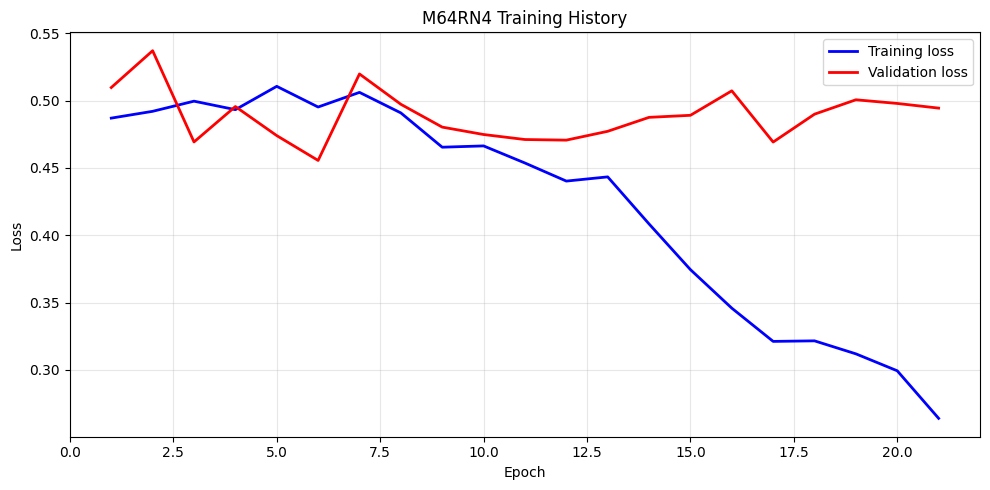

Plot saved → training_history.png

step4_train.py verified successfully.


In [16]:
# ── When training data is available, run this ─────────────────────────────────
# Uncomment and run once step2_patching.py has produced the numpy files

# X, y = load_training_data(
#     patches_path="training_patches.npy",
#     labels_path="training_labels_rad.npy"
# )
# X_train, X_val, y_train, y_val = prepare_data(X, y, val_split=0.1)
# history, model = train(X_train, X_val, y_train, y_val)
# plot_training_history(history)

# ── For now — verify everything works with synthetic data ─────────────────────
print("Testing training pipeline with synthetic data...")
np.random.seed(42)

N       = 2000
X_fake  = np.random.randn(N, 49, 49, 1).astype(np.float32)
y_fake  = np.random.uniform(-np.pi/2, np.pi/2, N).astype(np.float32)

split        = int(0.9 * N)
X_train_fake = X_fake[:split]
X_val_fake   = X_fake[split:]
y_train_fake = y_fake[:split]
y_val_fake   = y_fake[split:]

history, model = train(
    X_train_fake, X_val_fake,
    y_train_fake, y_val_fake,
    epochs=30,
    batch_size=64,
    model_save_path="best_model.keras"
)

plot_training_history(history)
print("\nstep4_train.py verified successfully.")